# Домашнее задание: Урок 27 — Полносвязные слои

## Задача: Прогнозирование сердечно-сосудистых заболеваний с помощью MLP

На практике мы работали с изображениями (Fashion MNIST). Теперь применим MLP к **табличным медицинским данным** — это другой, но не менее важный сценарий использования нейросетей.

**Датасет:** Heart Disease — 13 медицинских показателей пациента, цель — предсказать наличие заболевания сердца (бинарная классификация: 0 или 1).

---

### ⏱ Оценка по частям:

| Часть | Описание | Баллы |
|-------|----------|-------|
| 1 | Загрузка данных + базовая модель | 30 |
| 2 | Эксперименты с архитектурой | 30 |
| 3 | Регуляризация | 20 |
| 4 | Анализ ошибок | 20 |
| **Итого** | | **100** |

---
## Часть 0: Загрузка данных (код дан — просто запустите)

Код ниже скачивает датасет, обрабатывает пропуски, нормализует признаки и создаёт DataLoader'ы.

> **Обратите внимание** — здесь бинарная классификация (1 выход + Sigmoid), а не мультиклассовая (10 выходов + CrossEntropy) как на практике. Это влияет на:
> - Выходной слой: `nn.Linear(..., 1)` + `nn.Sigmoid()`
> - Функцию потерь: `nn.BCELoss()` вместо `nn.CrossEntropyLoss()`
> - Предсказание: `(output >= 0.5).float()` вместо `output.argmax()`

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

# --- Загрузка датасета Heart Disease ---
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

data = pd.read_csv(url, names=columns, na_values='?')
data = data.dropna()
data['target'] = (data['target'] > 0).astype(int)

print(f"Размер датасета: {data.shape}")
print(f"Распределение классов:\n{data['target'].value_counts()}")
print(f"\nПризнаки:")
features_info = {
    'age': 'Возраст', 'sex': 'Пол', 'cp': 'Тип боли в груди',
    'trestbps': 'АД в покое', 'chol': 'Холестерин', 'fbs': 'Сахар натощак',
    'restecg': 'ЭКГ в покое', 'thalach': 'Макс ЧСС', 'exang': 'Стенокардия',
    'oldpeak': 'Депрессия ST', 'slope': 'Наклон ST', 'ca': 'Сосуды (флюоро)',
    'thal': 'Талассемия'
}
for col, desc in features_info.items():
    print(f"  {col:10s} — {desc}")

Размер датасета: (297, 14)
Распределение классов:
target
0    160
1    137
Name: count, dtype: int64

Признаки:
  age        — Возраст
  sex        — Пол
  cp         — Тип боли в груди
  trestbps   — АД в покое
  chol       — Холестерин
  fbs        — Сахар натощак
  restecg    — ЭКГ в покое
  thalach    — Макс ЧСС
  exang      — Стенокардия
  oldpeak    — Депрессия ST
  slope      — Наклон ST
  ca         — Сосуды (флюоро)
  thal       — Талассемия


In [ ]:
# --- Подготовка данных для PyTorch ---
X = data.drop('target', axis=1).values
y = data['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Стандартизация — ОБЯЗАТЕЛЬНА для нейросетей!
# Без неё признаки с большими значениями (cholesterol ~200) будут
# доминировать над маленькими (sex: 0/1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # transform, НЕ fit_transform! (утечка данных)

# Конвертация в тензоры
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),   batch_size=32, shuffle=False)

input_size = X_train.shape[1]
print(f"\nКоличество признаков: {input_size}")
print(f"Обучающая выборка: {len(X_train)}, Тестовая: {len(X_test)}")


Количество признаков: 13
Обучающая выборка: 237, Тестовая: 60


### Вспомогательная функция для обучения (дана)

Используйте эту функцию для обучения моделей в заданиях ниже.

In [ ]:
def train_model(model, train_loader, test_loader, epochs=100, lr=0.001):
    """
    Обучает модель и возвращает историю.
    Для бинарной классификации с Sigmoid на выходе.
    """
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            predicted = (outputs >= 0.5).float()
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(100 * correct / total)

        model.eval()
        running_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_loss += loss.item() * inputs.size(0)
                predicted = (outputs >= 0.5).float()
                correct += (predicted == targets).sum().item()
                total += targets.size(0)
        history['test_loss'].append(running_loss / total)
        history['test_acc'].append(100 * correct / total)

        if (epoch + 1) % 20 == 0:
            print(f"Эпоха {epoch+1:3d}/{epochs} | "
                  f"Train Acc: {history['train_acc'][-1]:.1f}% | "
                  f"Test Acc: {history['test_acc'][-1]:.1f}%")

    return history


def plot_history(history, title=""):
    """Рисует графики обучения."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['test_loss'], label='Test')
    ax1.set_title(f'{title} — Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['test_acc'], label='Test')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Часть 1: Базовая MLP модель (30 баллов)

### Задание 1.1
Создайте MLP модель со следующей архитектурой:
- Входной слой: 13 признаков
- Скрытый слой: 16 нейронов + ReLU
- Выходной слой: 1 нейрон + Sigmoid

> Вспомните с практики: `nn.Sigmoid()` на выходе, потому что это бинарная классификация. На практике мы не ставили Softmax, потому что `CrossEntropyLoss` включает его. Здесь мы используем `BCELoss`, который **не** включает Sigmoid — его нужно добавить явно.

In [ ]:
# Ваш код здесь
class HeartMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(13, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Создайте модель и выведите количество параметров

model = HeartMLP()
print(model)

print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

HeartMLP(
  (model): Sequential(
    (0): Linear(in_features=13, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
Параметров: 241


### Задание 1.2
Обучите модель на 100 эпох с lr=0.001 и визуализируйте обучение.

Эпоха  20/100 | Train Acc: 81.4% | Test Acc: 81.7%
Эпоха  40/100 | Train Acc: 85.2% | Test Acc: 86.7%
Эпоха  60/100 | Train Acc: 86.1% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 86.9% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 87.8% | Test Acc: 83.3%


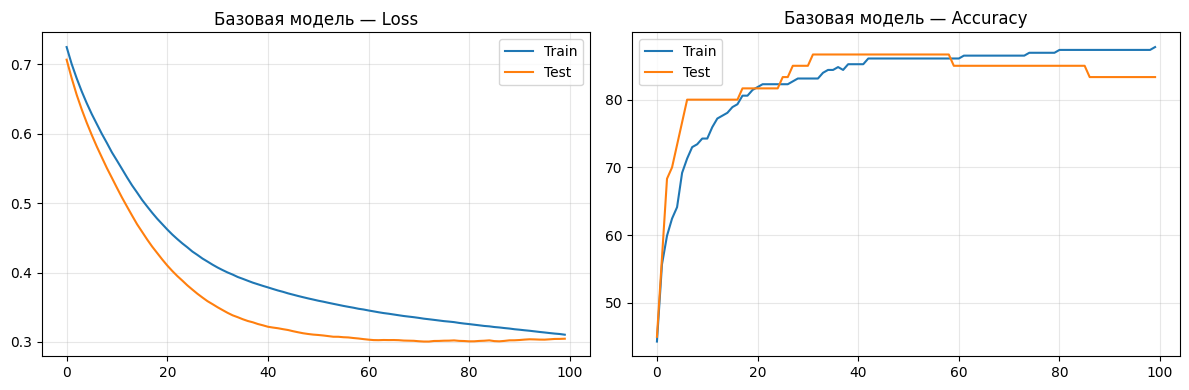

In [ ]:
# Ваш код здесь
torch.manual_seed(42)
model = HeartMLP()
history = train_model(model, train_loader, test_loader, epochs=100, lr=0.001)
plot_history(history, "Базовая модель")

### Вопрос 1.3 (ответьте текстом в ячейке ниже)

Посмотрите на графики:
1. Есть ли признаки переобучения?
2. Какой test accuracy вы получили?
3. Достаточно ли 100 эпох или нужно больше?

In [ ]:
# Ваш ответ текстом (в комментарии или print)
print("1. Есть лёгкое переобучение, train accuracy продолжает расти, а test accuracy начинает снижаться")
print("2. Финальное значение на 100 эпохе -- 83.3%. Самое высокое значение было на 40 эпохе -- 86.7%")
print("3. Да, достаточно и даже слишком много, ближе к 100 жпохе качество начинает ухудшаться.")

1. Есть лёгкое переобучение, train accuracy продолжает расти, а test accuracy начинает снижаться
2. Финальное значение на 100 эпохе -- 83.3%. Самое высокое значение было на 40 эпохе -- 86.7%
3. Да, достаточно и даже слишком много, ближе к 100 жпохе качество начинает ухудшаться.


---
## Часть 2: Эксперименты с архитектурой (30 баллов)

### Задание 2.1: Сравните три архитектуры

Как на практике, создайте и сравните:
- **Модель A:** 1 скрытый слой [16]
- **Модель B:** 2 скрытых слоя [16, 8]
- **Модель C:** 3 скрытых слоя [32, 16, 8]

Используйте ReLU между слоями, Sigmoid на выходе. Обучите каждую на 100 эпох.

> **Подвох:** датасет маленький (~240 обучающих примеров, 13 признаков). Подумайте, как это влияет на выбор архитектуры. Нужна ли вам сеть с 32 нейронами?

Эпоха  20/100 | Train Acc: 81.4% | Test Acc: 81.7%
Эпоха  40/100 | Train Acc: 85.2% | Test Acc: 86.7%
Эпоха  60/100 | Train Acc: 86.1% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 86.9% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 87.8% | Test Acc: 83.3%
Эпоха  20/100 | Train Acc: 85.2% | Test Acc: 85.0%
Эпоха  40/100 | Train Acc: 86.1% | Test Acc: 83.3%
Эпоха  60/100 | Train Acc: 87.8% | Test Acc: 78.3%
Эпоха  80/100 | Train Acc: 89.0% | Test Acc: 81.7%
Эпоха 100/100 | Train Acc: 90.7% | Test Acc: 83.3%
Эпоха  20/100 | Train Acc: 85.7% | Test Acc: 86.7%
Эпоха  40/100 | Train Acc: 91.1% | Test Acc: 83.3%
Эпоха  60/100 | Train Acc: 93.2% | Test Acc: 80.0%
Эпоха  80/100 | Train Acc: 95.8% | Test Acc: 80.0%
Эпоха 100/100 | Train Acc: 98.7% | Test Acc: 80.0%


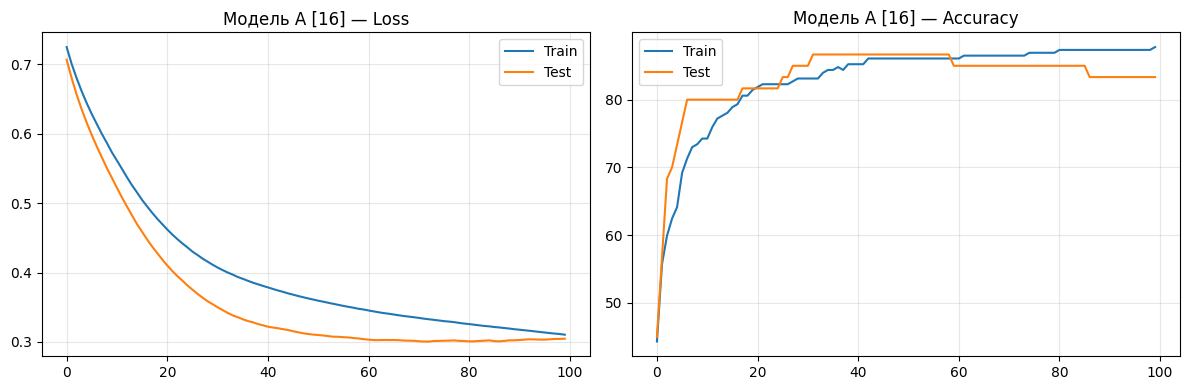

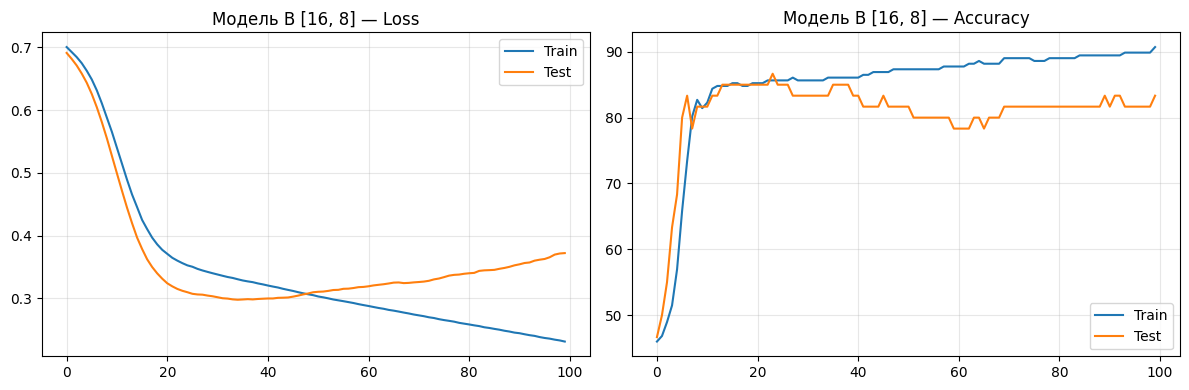

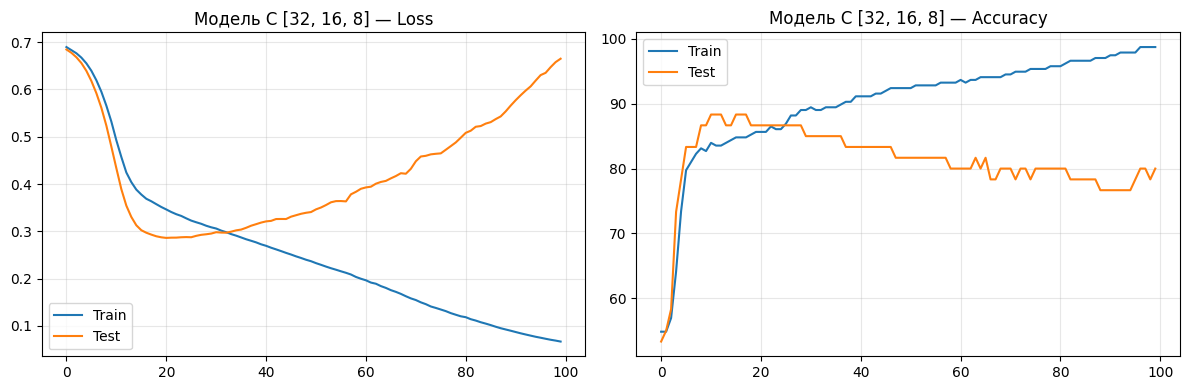

In [ ]:
# Ваш код здесь

class DeepMLP(nn.Module):
    def __init__(self, input_size, hidden_layers):
        super().__init__()

        layers = []
        prev_size = input_size

        # Скрытые слои
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size

        # Выходной слой
        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())  # обязательно для BCELoss

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

torch.manual_seed(42)

model_A = DeepMLP(input_size, [16])
history_A = train_model(model_A, train_loader, test_loader, epochs=100, lr=0.001)

model_B = DeepMLP(input_size, [16, 8])
history_B = train_model(model_B, train_loader, test_loader, epochs=100, lr=0.001)

model_C = DeepMLP(input_size, [32, 16, 8])
history_C = train_model(model_C, train_loader, test_loader, epochs=100, lr=0.001)

plot_history(history_A, "Модель A [16]")
plot_history(history_B, "Модель B [16, 8]")
plot_history(history_C, "Модель C [32, 16, 8]")


### Задание 2.2: Сравните функции активации

Используя архитектуру-победителя из 2.1, сравните: ReLU, Sigmoid, Tanh, LeakyReLU.

Постройте сравнительный график test accuracy.


Обучение модели с ReLU
Эпоха  20/100 | Train Acc: 81.4% | Test Acc: 81.7%
Эпоха  40/100 | Train Acc: 85.2% | Test Acc: 86.7%
Эпоха  60/100 | Train Acc: 86.1% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 86.9% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 87.8% | Test Acc: 83.3%

Обучение модели с Sigmoid
Эпоха  20/100 | Train Acc: 81.0% | Test Acc: 86.7%
Эпоха  40/100 | Train Acc: 82.7% | Test Acc: 91.7%
Эпоха  60/100 | Train Acc: 84.0% | Test Acc: 86.7%
Эпоха  80/100 | Train Acc: 84.8% | Test Acc: 86.7%
Эпоха 100/100 | Train Acc: 85.2% | Test Acc: 83.3%

Обучение модели с Tanh
Эпоха  20/100 | Train Acc: 82.3% | Test Acc: 88.3%
Эпоха  40/100 | Train Acc: 85.2% | Test Acc: 85.0%
Эпоха  60/100 | Train Acc: 85.2% | Test Acc: 83.3%
Эпоха  80/100 | Train Acc: 85.2% | Test Acc: 83.3%
Эпоха 100/100 | Train Acc: 85.7% | Test Acc: 83.3%

Обучение модели с LeakyReLU
Эпоха  20/100 | Train Acc: 75.5% | Test Acc: 83.3%
Эпоха  40/100 | Train Acc: 85.7% | Test Acc: 86.7%
Эпоха  60/100 | Train Acc: 86

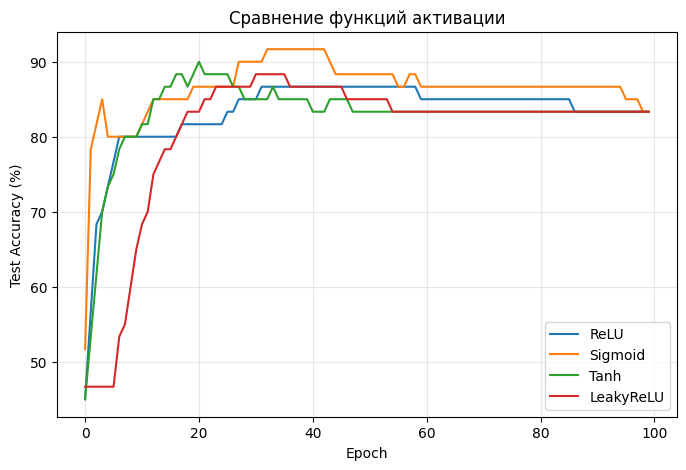

In [ ]:
class DeepMLP(nn.Module):
    def __init__(self, input_size, hidden_layers, activation):
        super().__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(activation())
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

torch.manual_seed(42)

histories = {}

activations = {
    "ReLU": nn.ReLU,
    "Sigmoid": nn.Sigmoid,
    "Tanh": nn.Tanh,
    "LeakyReLU": nn.LeakyReLU
}

for name, activation in activations.items():
    print(f"\nОбучение модели с {name}")
    model = DeepMLP(input_size, [16], activation)
    histories[name] = train_model(
        model,
        train_loader,
        test_loader,
        epochs=100,
        lr=0.001
    )

plt.figure(figsize=(8,5))

for name in histories:
    plt.plot(histories[name]['test_acc'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Сравнение функций активации")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Вопрос 2.3

Какая архитектура и активация показали лучший результат? Почему?

> Подсказка: для маленького датасета часто лучше простые модели. Почему?

In [ ]:
print("Лучший результат:")
print("Архитектура: 1 скрытый слой [16]; Активация: Sigmoid")
print("Sigmoid дает более плавные границы")
print("Простые модели лучше работают для маленького датасета потому что меньше параметров и меньше риск переобуения")

Лучший результат:
Архитектура: 1 скрытый слой [16]; Активация: Sigmoid
Sigmoid дает более плавные границы
Простые модели лучше работают для маленького датасета потому что меньше параметров и меньше риск переобуения


---
## Часть 3: Регуляризация (20 баллов)

На маленьком датасете переобучение — главная проблема. Попробуем бороться с ним.

### Задание 3.1: Dropout

Возьмите лучшую архитектуру и добавьте `nn.Dropout(p)` между скрытыми слоями. Сравните p = 0.0, 0.2, 0.5.

> С практики: Dropout случайно "выключает" часть нейронов во время обучения. Это заставляет сеть не полагаться на отдельные нейроны, а распределять знания.


Обучение с Dropout p=0.0
Эпоха  20/100 | Train Acc: 81.4% | Test Acc: 81.7%
Эпоха  40/100 | Train Acc: 85.2% | Test Acc: 86.7%
Эпоха  60/100 | Train Acc: 86.1% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 86.9% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 87.8% | Test Acc: 83.3%

Обучение с Dropout p=0.2
Эпоха  20/100 | Train Acc: 82.3% | Test Acc: 88.3%
Эпоха  40/100 | Train Acc: 86.1% | Test Acc: 88.3%
Эпоха  60/100 | Train Acc: 85.7% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 86.5% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 87.3% | Test Acc: 81.7%

Обучение с Dropout p=0.5
Эпоха  20/100 | Train Acc: 78.9% | Test Acc: 83.3%
Эпоха  40/100 | Train Acc: 83.5% | Test Acc: 86.7%
Эпоха  60/100 | Train Acc: 83.1% | Test Acc: 86.7%
Эпоха  80/100 | Train Acc: 83.5% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 82.7% | Test Acc: 85.0%


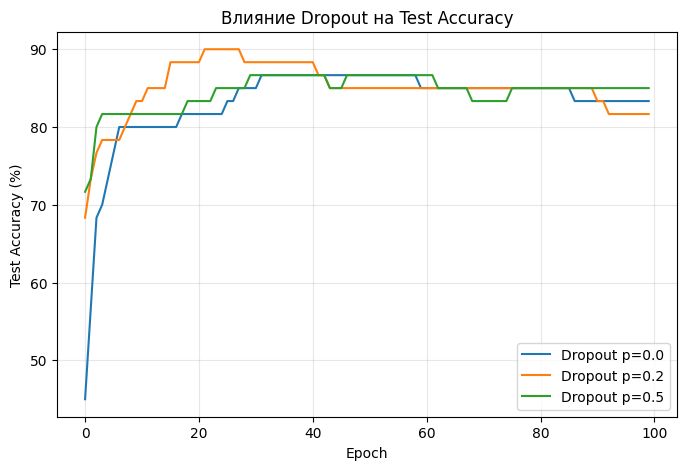

In [ ]:
class MLPWithDropout(nn.Module):
    def __init__(self, input_size, hidden_layers, dropout_p):
        super().__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))  # Dropout после активации
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


torch.manual_seed(42)

dropout_values = [0.0, 0.2, 0.5]
histories_dropout = {}

for p in dropout_values:
    print(f"\nОбучение с Dropout p={p}")
    model = MLPWithDropout(input_size, [16], dropout_p=p)

    histories_dropout[p] = train_model(
        model,
        train_loader,
        test_loader,
        epochs=100,
        lr=0.001
    )

plt.figure(figsize=(8,5))

for p in dropout_values:
    plt.plot(histories_dropout[p]['test_acc'], label=f"Dropout p={p}")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Влияние Dropout на Test Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Задание 3.2: L2-регуляризация (Weight Decay)

В PyTorch L2-регуляризация задаётся через параметр `weight_decay` в оптимизаторе:

```python
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
```

Сравните weight_decay = 0, 0.001, 0.01, 0.1.


Обучение с weight_decay=0

Обучение с weight_decay=0.001

Обучение с weight_decay=0.01

Обучение с weight_decay=0.1


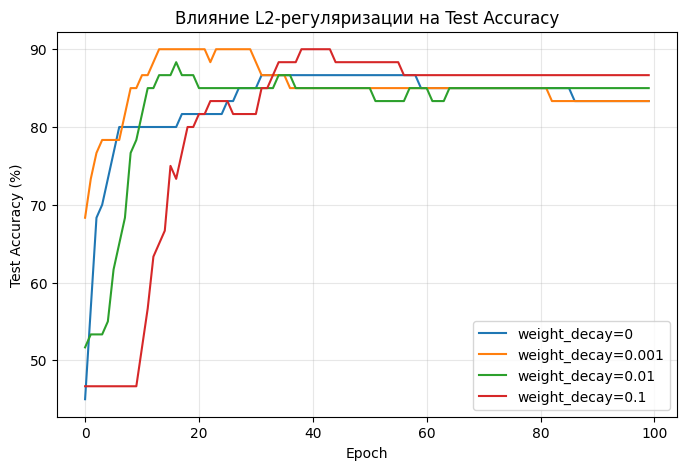

In [ ]:
def train_model_l2(model, train_loader, test_loader, epochs=100, lr=0.001, weight_decay=0.0):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            predicted = (outputs >= 0.5).float()
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(100 * correct / total)

        model.eval()
        running_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_loss += loss.item() * inputs.size(0)
                predicted = (outputs >= 0.5).float()
                correct += (predicted == targets).sum().item()
                total += targets.size(0)
        history['test_loss'].append(running_loss / total)
        history['test_acc'].append(100 * correct / total)

    return history

torch.manual_seed(42)

weight_decays = [0, 0.001, 0.01, 0.1]
histories_l2 = {}

for wd in weight_decays:
    print(f"\nОбучение с weight_decay={wd}")
    model = DeepMLP(input_size, [16], nn.ReLU)
    histories_l2[wd] = train_model_l2(
        model,
        train_loader,
        test_loader,
        epochs=100,
        lr=0.001,
        weight_decay=wd
    )


plt.figure(figsize=(8,5))

for wd in weight_decays:
    plt.plot(histories_l2[wd]['test_acc'], label=f"weight_decay={wd}")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Влияние L2-регуляризации на Test Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Вопрос 3.3

Какой метод регуляризации помог больше? Объясните почему.

In [ ]:
print("Лучший результат p = 0.2")
print("L2-регуляризация не дала заметного скачака accuracy")
print("L2 работает мягче")
print("Для маленьких датасетов dropout жффективнее, но слишком сильная регуляризация ухудшает результат.")

Лучший результат p = 0.2
L2-регуляризация не дала заметного скачака accuracy
L2 работает мягче
Для маленьких датасетов dropout жффективнее, но слишком сильная регуляризация ухудшает результат.


---
## Часть 4: Анализ результатов (20 баллов)

### Задание 4.1: Матрица ошибок

Для лучшей модели постройте confusion matrix и рассчитайте метрики: accuracy, precision, recall, F1.

> В медицине **recall** (полнота) особенно важен: лучше ложная тревога, чем пропущенная болезнь!

Эпоха  20/100 | Train Acc: 81.4% | Test Acc: 81.7%
Эпоха  40/100 | Train Acc: 85.2% | Test Acc: 86.7%
Эпоха  60/100 | Train Acc: 86.1% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 86.9% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 87.8% | Test Acc: 83.3%


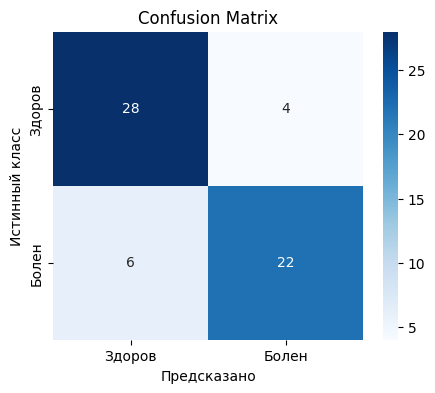

              precision    recall  f1-score   support

      Здоров       0.82      0.88      0.85        32
       Болен       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



In [ ]:
# Ваш код здесь
from sklearn.metrics import confusion_matrix, classification_report

best_model = DeepMLP(input_size, [16], nn.ReLU)
train_model(best_model, train_loader, test_loader)

best_model.eval()

with torch.no_grad():
    outputs = best_model(X_test_t)
    preds = (outputs >= 0.5).float().cpu().numpy()

preds = preds.flatten()

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Здоров", "Болен"],
            yticklabels=["Здоров", "Болен"])

plt.xlabel("Предсказано")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, preds, target_names=['Здоров', 'Болен']))

### Задание 4.2: Важность признаков

Для однослойной модели (1 скрытый слой) посмотрите на **абсолютные значения весов** первого слоя — это грубая оценка важности признаков.

```python
weights = model.fc1.weight.data.abs().mean(dim=0)  # Средний абсолютный вес по нейронам
```

Постройте гистограмму важности признаков. Какие 3 признака самые важные?

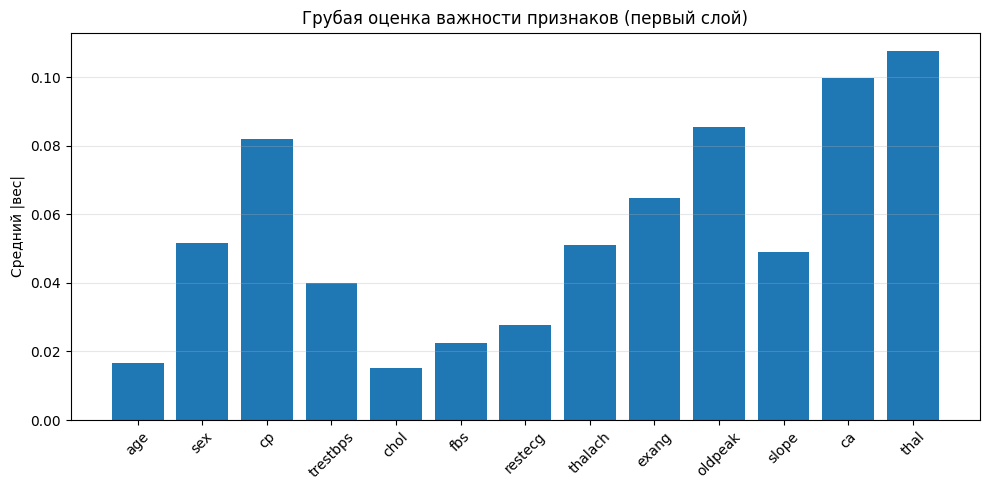

Топ-3 самых важных признака:
thal — важность 0.1076
ca — важность 0.0998
oldpeak — важность 0.0856


In [ ]:
feature_names = data.drop('target', axis=1).columns

first_layer = model.model[0]

weights = first_layer.weight.data.abs().mean(dim=0)
weights = weights.cpu().numpy()

plt.figure(figsize=(10,5))
plt.bar(feature_names, weights)
plt.xticks(rotation=45)
plt.ylabel("Средний |вес|")
plt.title("Грубая оценка важности признаков (первый слой)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

top3_idx = np.argsort(weights)[-3:][::-1]

print("Топ-3 самых важных признака:")
for i in top3_idx:
    print(f"{feature_names[i]} — важность {weights[i]:.4f}")


### Вопрос 4.3

Совпадают ли самые важные признаки с медицинскими ожиданиями? Например, `thalach` (макс ЧСС) и `cp` (тип боли в груди) известны как сильные предикторы сердечных заболеваний.

In [ ]:
print("1. Талассемия (thal) это сильный индикатор ишемической болезни сердца. Это сильный индикатор.")
print("2. Количество поражённых сосудов (ca) напрямую отражает поражения тела.")
print("3. Депрессия ST (oldpeak) это классический признак ишемии миокарда. Все эти признаки являются важными признаками в медицине.")

1. Талассемия (thal) это сильный индикатор ишемической болезни сердца. Это сильный индикатор.
2. Количество поражённых сосудов (ca) напрямую отражает поражения тела.
3. Депрессия ST (oldpeak) это классический признак ишемии миокарда. Все эти признаки являются важными признаками в медицине.


---
## ⭐ Бонус (необязательно)

Реализуйте функцию, которая принимает данные нового пациента и выдаёт:
- Вероятность заболевания
- Прогноз (Здоров / Болен)

```python
def predict_patient(model, scaler, patient_data):
    """
    patient_data: dict с ключами 'age', 'sex', 'cp', ...
    Возвращает: (прогноз, вероятность)
    """
    # TODO: ваш код
    pass

# Пример:
# patient = {'age': 55, 'sex': 1, 'cp': 3, 'trestbps': 140, 'chol': 250,
#            'fbs': 0, 'restecg': 0, 'thalach': 150, 'exang': 1,
#            'oldpeak': 2.0, 'slope': 2, 'ca': 1, 'thal': 7}
# predict_patient(best_model, scaler, patient)
```

In [ ]:
# Ваш код здесь (бонус)